# HMM-mixed MVO

Supervised HMM on inner train (through 2007-07-09). Validation (2007-07-10 to 2014-01-03) is used for a four-line regime plot and a 60-day mean-variance backtest.

Mixing is **not** a row percentage (not 10% real / 90% synth). Both methods keep the same real lookback of 60 days × 10 assets and **column-stack** `n` extra synthetic 60×10 windows. Markowitz is fit on the expanded matrix, then synth weights are summed back onto the 10 real assets.

- **hmm-diffusion**: `n` contiguous 60×10 windows from the specialist pool for predicted regime `k*`. `k*` is the **window average argmax** of the open-loop daily labels on that hold.
- **mixed**: `n` contiguous 60×10 windows from `trained_diffusion_withoutregime/generated_data.csv`.

On each hold the regime forecast uses the transition matrix only. Emissions on that hold are applied after scoring, and only on those 60 days.

Run scripts 01–04 first so regime labels and specialist pools exist. Markowitz is sum-to-1 with shorts allowed; no max-weight cap.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config

cfg = load_config()
bootstrap_imports()

from hmmdiff import data, models, plots, pools, regimes
from hmmdiff.mvo import (
    load_specialist_pools,
    load_uncond_windows,
    run_mvo_backtest,
    run_scale_check,
    walk_open_loop,
)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

HORIZON = 63
STEP = 63
LOOKBACK = 252
MIX_GRID = list(range(0, 11))
RANDOM_STATE = 42
N_REGIMES = int(cfg["regimes"]["n_regimes"])
TOP_K = int(cfg["hmm"]["top_k"])
ASSET_COLS = list(cfg["data"]["asset_columns"])
UNCOND_CSV = REPO_ROOT / "trained_diffusion_withoutregime" / "generated_data.csv"

print(
    f"{N_REGIMES} regimes, lookback {LOOKBACK}, hold {HORIZON}, step {STEP}, "
    f"mix grid {MIX_GRID[0]}..{MIX_GRID[-1]}"
)

5 regimes, lookback 252, hold 63, step 63, mix grid 0..10


## Setup


In [2]:
returns = data.load_returns(cfg)
splits = data.compute_splits(len(returns), cfg)
labels = regimes.load_labels(config_path(cfg, "regime_labels"))
regime_labels = labels.labels.astype(int)

train_data, val_data = data.build_model_frames(returns, regime_labels, cfg)
val_regimes = regime_labels[splits.train_val_split : splits.train_val_split + len(val_data)]

val_dates = pd.to_datetime(returns["date"].iloc[splits.train_val_split : splits.train_end])
inner_dates = pd.to_datetime(returns["date"].iloc[: splits.train_val_split])

log_panel = data.build_multivariate_log_returns(cfg)[ASSET_COLS]
simple_panel = np.expm1(log_panel)
simple_panel.index = pd.to_datetime(simple_panel.index)

pools_root = config_path(cfg, "pools")
if not pools.pools_available(pools_root, N_REGIMES):
    raise FileNotFoundError(
        f"Specialist pools not found under {pools_root}. Run scripts 03 and 04."
    )
specialist_pools = load_specialist_pools(pools_root, N_REGIMES)
uncond_windows = load_uncond_windows(UNCOND_CSV)

print(f"returns      {len(returns):>6}  {returns['date'].iloc[0]} to {returns['date'].iloc[-1]}")
print(f"inner train  {splits.n_train_inner:>6}  {inner_dates.iloc[0].date()} to {inner_dates.iloc[-1].date()}")
print(f"validation   {splits.n_val:>6}  {val_dates.iloc[0].date()} to {val_dates.iloc[-1].date()}")
print(f"10-asset panel {len(simple_panel):>5}  {simple_panel.index[0].date()} to {simple_panel.index[-1].date()}")
print(f"uncond windows {uncond_windows.shape}")
print(f"specialist pools {[specialist_pools[k].shape for k in range(N_REGIMES)]}")

returns        9031  1988-01-20 to 2022-08-31
inner train    5079  1988-01-20 to 2007-07-09
validation     1694  2007-07-10 to 2014-01-03
10-asset panel  5653  2001-01-01 to 2022-08-31
uncond windows (1024, 128, 10)
specialist pools [(128, 128, 10), (128, 128, 10), (128, 128, 10), (128, 128, 10), (128, 128, 10)]


## Fit supervised HMM


In [3]:
init_dist = models.initial_distribution(train_data, N_REGIMES)
supervised = models.fit_supervised_hmm(train_data, N_REGIMES, cfg)

index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")
print("Posterior transition matrix")
display(pd.DataFrame(supervised.transmat.round(3), index=index, columns=columns))
print("Emission parameters")
display(supervised.summary())
print("Initial distribution (inner-train frequencies)")
display(pd.Series(init_dist, index=range(N_REGIMES), name="pi0"))

sample: 100%|██████████| 300/300 [00:13<00:00, 22.38it/s, 31 steps of size 1.72e-01. acc. prob=0.84] 


Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0020,0.0010,0.0000,0.0000
1,0.0010,0.9970,0.0010,0.0010,0.0000
2,0.0010,0.0020,0.9940,0.0020,0.0010
3,0.0000,0.0000,0.0110,0.9880,0.0000
4,0.0020,0.0010,0.0020,0.0120,0.9830


Emission parameters


,mean,sigma
regime,,
0,0.0087,0.5028
1,0.0202,0.6764
2,0.0043,0.9672
3,-0.0383,1.3822
4,-0.0355,1.9231


Initial distribution (inner-train frequencies)


0   0.2648
1   0.3227
2   0.2973
3   0.0965
4   0.0187
Name: pi0, dtype: float64

## Rolling open-loop forecast


In [4]:
walk = walk_open_loop(
    train_data.emission.values,
    val_data.emission.values,
    supervised.transmat,
    supervised.mu,
    supervised.sigma,
    init_dist,
    horizon=HORIZON,
    step=STEP,
)

print(f"holds {len(walk.hold_starts)}  first val day {val_dates.iloc[0].date()}")
print(
    "hmm-diffusion k* = window average argmax; "
    f"first hold k* {int(walk.hold_k_star[0])}  last hold k* {int(walk.hold_k_star[-1])}"
)
print(
    "open-loop days filled",
    int(np.isfinite(walk.daily_argmax).sum()),
    "of",
    len(val_regimes),
)

holds 26  first val day 2007-07-10
hmm-diffusion k* = window average argmax; first hold k* 1  last hold k* 1
open-loop days filled 1638 of 1694


## Regime plot and accuracy

Three comparisons versus clustering truth:

1. **Forward-backward** — daily argmax of smoothed regime probabilities (uses emissions). Compared with daily clustering labels.
2. **Daily argmax** — each day's argmax of the open-loop regime probability (transition matrix only). Compared with daily clustering labels.
3. **Window average argmax** — one occupancy label per 60-day hold, copied to every day in that hold. Compared with daily clustering labels. **hmm-diffusion MVO samples all `n` synth windows from this regime's pool.**


100%|██████████| 1694/1694 [00:00<00:00, 87986.22it/s]
1694it [00:00, 97772.82it/s]

Validation does not contain regimes [0]; accuracy uses observed labels.


,truth,accuracy
estimate,,
Forward-backward,daily clustering labels,0.6340
Daily argmax,daily clustering labels,0.5177
Window average argmax,daily clustering labels,0.5183


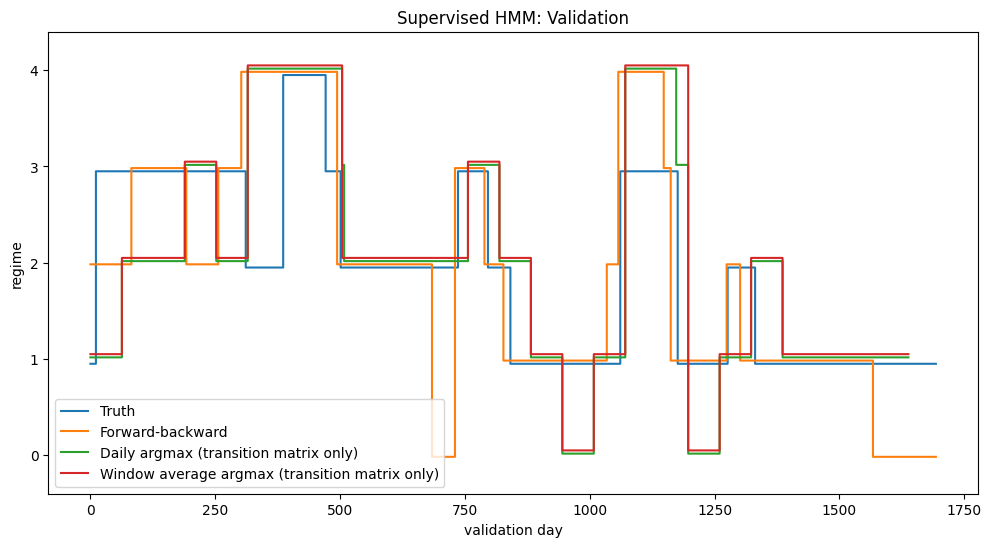

In [5]:
fb_probs, fb_est = models.estimate_states(
    supervised, val_data.emission.values, init_dist, N_REGIMES
)

present = sorted(set(val_regimes.tolist()))
missing = [k for k in range(N_REGIMES) if k not in present]
if missing:
    print(f"Validation does not contain regimes {missing}; accuracy uses observed labels.")

fb_acc = models.accuracy_report(val_regimes, fb_est, fb_probs, N_REGIMES, TOP_K)

daily_mask = np.isfinite(walk.daily_argmax)
daily_est = walk.daily_argmax[daily_mask].astype(int)
daily_truth = val_regimes[daily_mask]
daily_score = walk.open_loop_pi[daily_mask]
daily_acc = models.accuracy_report(daily_truth, daily_est, daily_score, N_REGIMES, TOP_K)

window_daily_score = np.full((len(val_regimes), N_REGIMES), np.nan)
for start in walk.hold_starts:
    sl = slice(int(start), int(start) + HORIZON)
    est_states = walk.daily_argmax[sl].astype(int)
    est_avg = np.eye(N_REGIMES)[est_states].mean(axis=0)
    window_daily_score[sl] = est_avg
window_daily_est = walk.window_argmax[daily_mask].astype(int)
window_daily_acc = models.accuracy_report(
    daily_truth, window_daily_est, window_daily_score[daily_mask], N_REGIMES, TOP_K
)

acc_table = pd.DataFrame(
    [
        {
            "estimate": "Forward-backward",
            "truth": "daily clustering labels",
            **fb_acc,
        },
        {
            "estimate": "Daily argmax",
            "truth": "daily clustering labels",
            **daily_acc,
        },
        {
            "estimate": "Window average argmax",
            "truth": "daily clustering labels",
            **window_daily_acc,
        },
    ]
).set_index("estimate")
display(acc_table[["truth", "accuracy"]])

plots.plot_regime_paths(
    {
        "Truth": val_regimes,
        "Forward-backward": fb_est,
        "Daily argmax (transition matrix only)": walk.daily_argmax,
        "Window average argmax (transition matrix only)": walk.window_argmax,
    },
    "Supervised HMM: Validation",
    jiggle=0.05,
)

## Scale check


In [6]:
first_hold_date = val_dates.iloc[int(walk.hold_starts[0])]
prior = simple_panel.loc[simple_panel.index < first_hold_date]
lookback_start = prior.index[-LOOKBACK]
real_ref = np.log1p(simple_panel.loc[lookback_start:val_dates.iloc[-1], ASSET_COLS].to_numpy())

scale = run_scale_check(real_ref, specialist_pools, uncond_windows, ASSET_COLS)
display(scale.table)
if not scale.ok:
    for line in scale.messages:
        print(f"[FAIL] {line}")
    raise SystemExit("Scale check failed; synth units do not match real MVO inputs.")
print("[OK] native log-return scale; simple-return std within 0.1×–10× of real")

,source,asset,native_std,simple_mean,simple_std,simple_min,simple_max,simple_p01,simple_p99
0,real,A001,0.0141,0.0004,0.0141,-0.0903,0.1158,-0.0442,0.0406
1,real,A004,0.0024,0.0002,0.0024,-0.0125,0.0133,-0.0063,0.0066
2,real,A006,0.0008,0.0001,0.0008,-0.0062,0.0056,-0.0022,0.0025
3,real,A008,0.0036,0.0003,0.0036,-0.0470,0.0287,-0.0118,0.0099
4,real,A009,0.0044,0.0003,0.0044,-0.0611,0.0486,-0.0115,0.0100
5,real,A011,0.0157,0.0005,0.0156,-0.1002,0.1123,-0.0485,0.0433
6,real,A012,0.0179,0.0005,0.0179,-0.1184,0.0926,-0.0521,0.0531
7,real,A013,0.0135,0.0002,0.0135,-0.0843,0.0859,-0.0411,0.0343
8,real,A014,0.0146,0.0003,0.0145,-0.0948,0.1060,-0.0423,0.0365
9,real,A015,0.0261,0.0005,0.0262,-0.1971,0.1868,-0.0827,0.0884


[OK] native log-return scale; simple-return std within 0.1×–10× of real


## MVO config

Lookback, hold, and step are trading-day counts. Later cells keep these windows and only change objective or constraints.


In [7]:
from hmmdiff.mvo.backtest import lookback_and_hold, window_vol_bucket
from hmmdiff.mvo.portfolio_core import TRADING_DAYS, sharpe_ratio

n_assets = len(ASSET_COLS)
mvo_config = pd.DataFrame(
    [
        ("lookback", LOOKBACK, "trading days for μ and Σ"),
        ("hold / horizon", HORIZON, "days the weights are held"),
        ("step", STEP, "days between consecutive hold starts"),
        ("non-overlapping", STEP == HORIZON, "step equals hold"),
        ("mix grid", f"{MIX_GRID[0]}–{MIX_GRID[-1]}", f"{len(MIX_GRID)} mix points"),
        ("n assets", n_assets, ", ".join(ASSET_COLS)),
        ("random state", RANDOM_STATE, "seed + hold_start + n_synth"),
        ("ridge", 1e-6, "covariance diagonal; raised if T ≤ n_feat"),
        ("k*", "window average argmax", "hmm-diffusion specialist pool"),
        ("default objective", "mean-variance", "later cells override"),
        ("default constraints", "unconstrained", "shorts allowed, no name cap"),
        ("synth window length", int(uncond_windows.shape[1]), "must be ≥ hold"),
        ("uncond pool size", int(uncond_windows.shape[0]), "regime-free CSV"),
        (
            "specialist pool size",
            int(next(iter(specialist_pools.values())).shape[0]),
            "windows per regime",
        ),
        ("train matrix n=0", f"{LOOKBACK} × {n_assets}", "real lookback only"),
        (
            f"train matrix n={MIX_GRID[-1]}",
            f"{LOOKBACK} × {n_assets * (1 + MIX_GRID[-1])}",
            "real plus column-stacked synth",
        ),
    ],
    columns=["parameter", "value", "note"],
)
display(mvo_config)

hold_rows = []
for i, start in enumerate(walk.hold_starts.tolist()):
    start = int(start)
    sliced = lookback_and_hold(
        simple_panel[ASSET_COLS], val_dates.to_numpy(), start, LOOKBACK, HORIZON
    )
    hold_labels = val_regimes[start : start + HORIZON]
    hold_rows.append(
        {
            "hold": i,
            "start": val_dates.iloc[start].date(),
            "end": val_dates.iloc[start + HORIZON - 1].date(),
            "complete": sliced is not None,
            "bucket": window_vol_bucket(hold_labels),
            "k_star": int(walk.hold_k_star[i]),
        }
    )
holds = pd.DataFrame(hold_rows)
print(
    f"holds scheduled {len(holds)}  complete {int(holds['complete'].sum())}  "
    f"skipped {int((~holds['complete']).sum())}  "
    f"first {holds['start'].iloc[0]}  last start {holds['start'].iloc[-1]}"
)
display(holds["bucket"].value_counts().rename_axis("bucket").to_frame("n_holds"))
display(holds["k_star"].value_counts().sort_index().rename_axis("k*").to_frame("n_holds"))

val_simple = simple_panel.reindex(pd.DatetimeIndex(val_dates))[ASSET_COLS]
ann_mu = val_simple.mean() * TRADING_DAYS
ann_sd = val_simple.std(ddof=0) * np.sqrt(TRADING_DAYS)
asset_stats = pd.DataFrame({"ann_mu": ann_mu, "ann_sd": ann_sd, "sharpe": ann_mu / ann_sd})
pair_corr = val_simple.corr().to_numpy()
mean_pair_corr = float(pair_corr[np.triu_indices_from(pair_corr, k=1)].mean())
ew = val_simple.mean(axis=1).to_numpy()
print(
    f"validation panel {val_simple.dropna(how='any').shape[0]} days  "
    f"mean pairwise corr {mean_pair_corr:.3f}  "
    f"equal-weight Sharpe {sharpe_ratio(ew):.3f}"
)
display(asset_stats.T)


,parameter,value,note
0,lookback,252,trading days for μ and Σ
1,hold / horizon,63,days the weights are held
2,step,63,days between consecutive hold starts
3,non-overlapping,True,step equals hold
4,mix grid,0–10,11 mix points
5,n assets,10,"A001, A004, A006, A008, A009, A011, A012, A013..."
6,random state,42,seed + hold_start + n_synth
7,ridge,0.0000,covariance diagonal; raised if T ≤ n_feat
8,k*,window average argmax,hmm-diffusion specialist pool
9,default objective,mean-variance,later cells override


holds scheduled 26  complete 26  skipped 0  first 2007-07-10  last start 2013-07-23


,n_holds
bucket,
low vol,16
high vol,10


,n_holds
k*,
0,2
1,8
2,9
3,2
4,5


validation panel 1694 days  mean pairwise corr 0.292  equal-weight Sharpe 0.460


,A001,A004,A006,A008,A009,A011,A012,A013,A014,A015
ann_mu,0.0758,0.0500,0.0299,0.0848,0.0740,0.0940,0.1034,0.0240,0.0321,0.1177
ann_sd,0.2368,0.0403,0.0137,0.0615,0.0733,0.2624,0.2986,0.2253,0.2413,0.4402
sharpe,0.3202,1.2430,2.1777,1.3786,1.0089,0.3582,0.3463,0.1067,0.1330,0.2675


## MVO backtest

`n_synth` is a count of extra synthetic series, not a mix percent. Real data size does not change with `n`.

hmm-diffusion samples contiguous 60-day windows from `pool_{k*}`. `k*` is the window average argmax of the open-loop daily labels on the hold. Mixed still draws contiguous 60-day slices from the regime-free CSV.



In [8]:
result = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    val_dates.to_numpy(),
    val_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=True,
)

n0 = result.windows.loc[result.windows["n_synth"] == 0]
if n0.empty:
    raise SystemExit("No completed MVO holds.")
hmm_n0 = n0.loc[n0["method"] == "hmm-diffusion", ["hold_start", "sharpe", "calmar"]]
mixed_n0 = n0.loc[n0["method"] == "mixed", ["hold_start", "sharpe", "calmar"]]
merged = hmm_n0.merge(mixed_n0, on="hold_start", suffixes=("_hmm", "_mixed"))
sharpe_gap = float(np.nanmax(np.abs(merged["sharpe_hmm"] - merged["sharpe_mixed"])))
calmar_gap = float(np.nanmax(np.abs(merged["calmar_hmm"] - merged["calmar_mixed"])))
print(f"holds scored {merged.shape[0]}  n=0 max |Δ Sharpe| {sharpe_gap:.6g}  |Δ Calmar| {calmar_gap:.6g}")
if sharpe_gap > 1e-10 or calmar_gap > 1e-10:
    raise SystemExit("n=0 hmm-diffusion and mixed should match.")

print("bucket counts at n=0")
display(n0.loc[n0["method"] == "hmm-diffusion", "bucket"].value_counts())
print(f"first hold {result.windows['start_date'].min().date()}  last hold start {result.windows['start_date'].max().date()}")

holds scored 26  n=0 max |Δ Sharpe| 0  |Δ Calmar| 0
bucket counts at n=0


bucket
low vol     16
high vol    10
Name: count, dtype: int64

first hold 2007-07-10  last hold start 2013-07-23


## Sharpe and Calmar

The x-axis `n synth` is how many synthetic 60×10 windows were column-stacked onto the real 60×10 lookback. It is not 10% real / 90% synth, 20% real / 80% synth, and so on.


Column-stack mix: real lookback stays 60 days × 10 assets. n=1 adds one 60×10 synth window (10 extra columns), not 10% synth rows.


,n_synth,real_rows,real_cols,synth_windows,synth_cols,train_matrix,synth_column_share
0,0,252,10,0,0,252 × 10,0.0000
1,1,252,10,1,10,252 × 20,0.5000
2,2,252,10,2,20,252 × 30,0.6667
3,3,252,10,3,30,252 × 40,0.7500
4,4,252,10,4,40,252 × 50,0.8000
5,5,252,10,5,50,252 × 60,0.8333
6,6,252,10,6,60,252 × 70,0.8571
7,7,252,10,7,70,252 × 80,0.8750
8,8,252,10,8,80,252 × 90,0.8889
9,9,252,10,9,90,252 × 100,0.9000


,method,n_synth,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,high vol,10,-0.2844,0.1140,3.1353,0.4530
22,mixed,0,high vol,10,-0.2844,0.1140,3.1353,0.4530
2,hmm-diffusion,1,high vol,10,1.5115,0.1043,11.4600,0.5051
24,mixed,1,high vol,10,1.8786,1.4674,-1.2988,0.1727
4,hmm-diffusion,2,high vol,10,1.9345,0.5452,1.6886,0.0571
26,mixed,2,high vol,10,1.6057,0.8303,11.1980,0.1804
6,hmm-diffusion,3,high vol,10,0.9813,0.6151,5.4829,0.0166
28,mixed,3,high vol,10,1.6135,1.0381,-0.6146,0.0010
8,hmm-diffusion,4,high vol,10,1.4543,1.1270,-0.7226,0.0001
30,mixed,4,high vol,10,1.0898,0.6672,-0.0709,0.0000


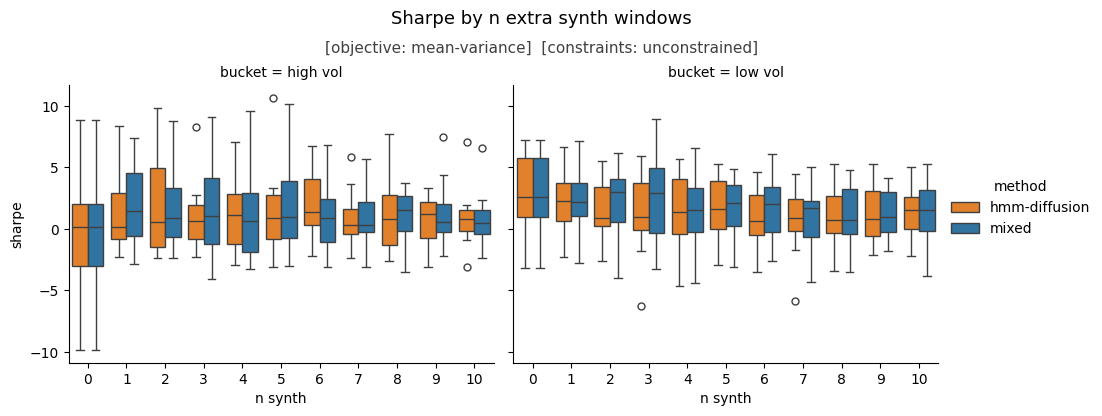

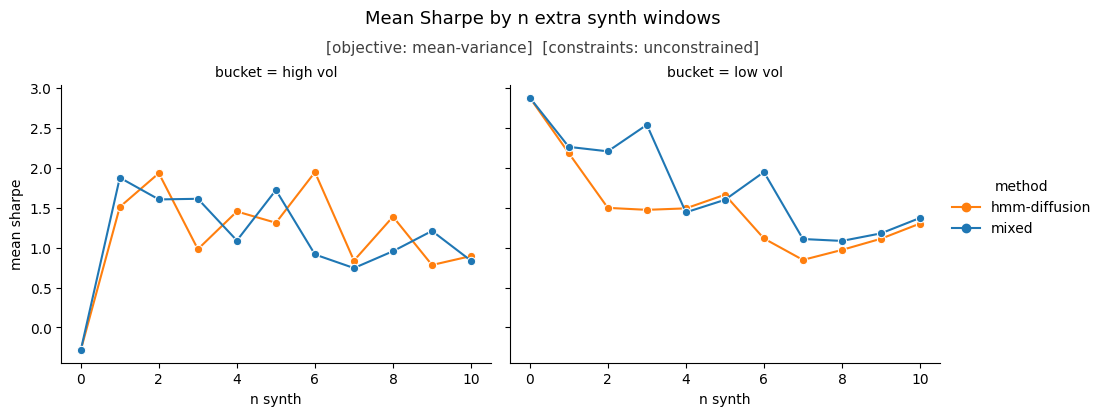

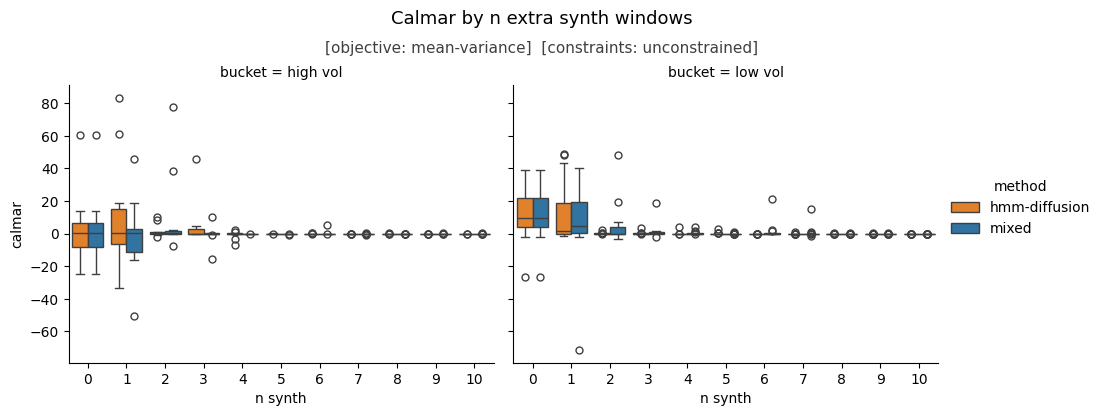

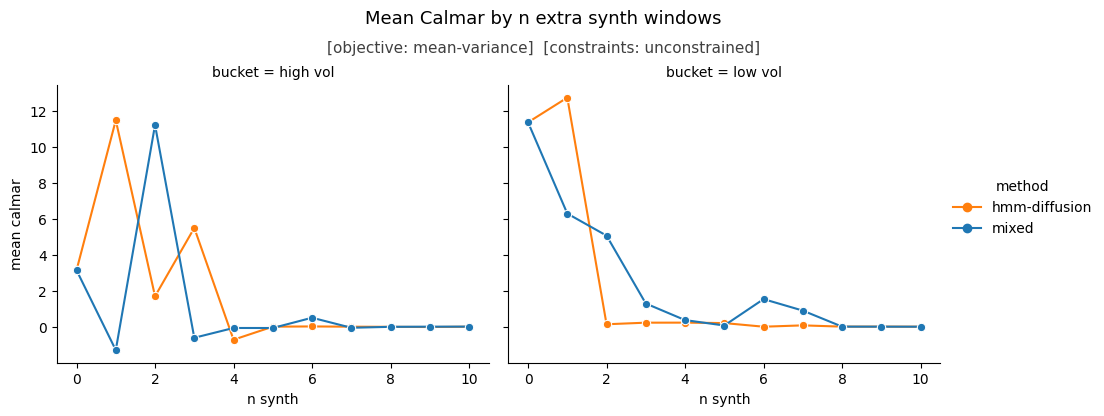

In [9]:
n_assets = len(ASSET_COLS)
mix_size = pd.DataFrame(
    {
        "n_synth": MIX_GRID,
        "real_rows": LOOKBACK,
        "real_cols": n_assets,
        "synth_windows": MIX_GRID,
        "synth_cols": [n_assets * n for n in MIX_GRID],
        "train_matrix": [f"{LOOKBACK} × {n_assets * (1 + n)}" for n in MIX_GRID],
        "synth_column_share": [n / (1 + n) if n else 0.0 for n in MIX_GRID],
    }
)
print(
    "Column-stack mix: real lookback stays 60 days × 10 assets. "
    "n=1 adds one 60×10 synth window (10 extra columns), not 10% synth rows."
)
display(mix_size)

display(result.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result.windows, "sharpe", objective="mean-variance", constraint="unconstrained"
)
plots.plot_mvo_means(
    result.windows, "sharpe", objective="mean-variance", constraint="unconstrained"
)
plots.plot_mvo_boxes(
    result.windows, "calmar", objective="mean-variance", constraint="unconstrained"
)
plots.plot_mvo_means(
    result.windows, "calmar", objective="mean-variance", constraint="unconstrained"
)

## Long-only MVO

Same mix, holds, and seeds as the unconstrained sweep. `allow_short=False` clips negative weights on the expanded columns, then renormalizes. Collapsed 10-asset weights stay nonnegative. This is clip-and-renorm, not a QP with `w ≥ 0`. `n=0` long-only will not match unconstrained `n=0`.


,method,n_synth,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,high vol,10,0.8754,0.3404,4.0307,0.4949
22,mixed,0,high vol,10,0.8754,0.3404,4.0307,0.4949
2,hmm-diffusion,1,high vol,10,1.5614,0.7560,7.1023,1.0747
24,mixed,1,high vol,10,1.5153,1.0939,5.5785,1.7926
4,hmm-diffusion,2,high vol,10,1.5866,0.7195,6.3851,0.9970
26,mixed,2,high vol,10,1.3342,0.8362,5.0553,1.1663
6,hmm-diffusion,3,high vol,10,1.1378,0.5578,5.3459,0.7726
28,mixed,3,high vol,10,1.2169,0.8025,5.1839,1.1281
8,hmm-diffusion,4,high vol,10,1.4164,0.7810,5.8459,1.0849
30,mixed,4,high vol,10,0.9558,0.7302,4.5872,1.0100


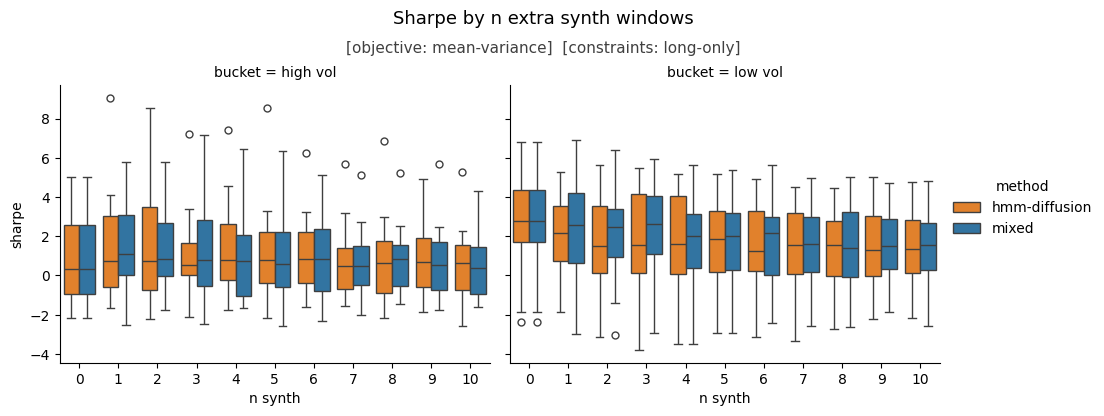

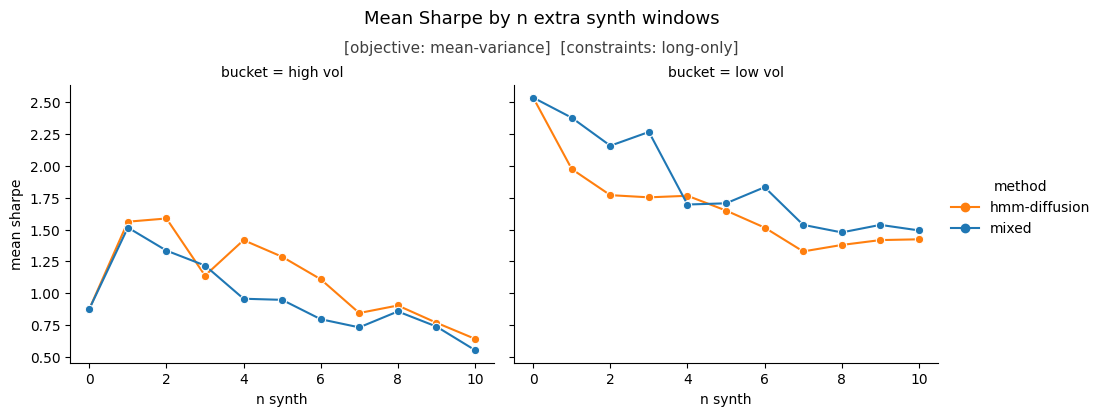

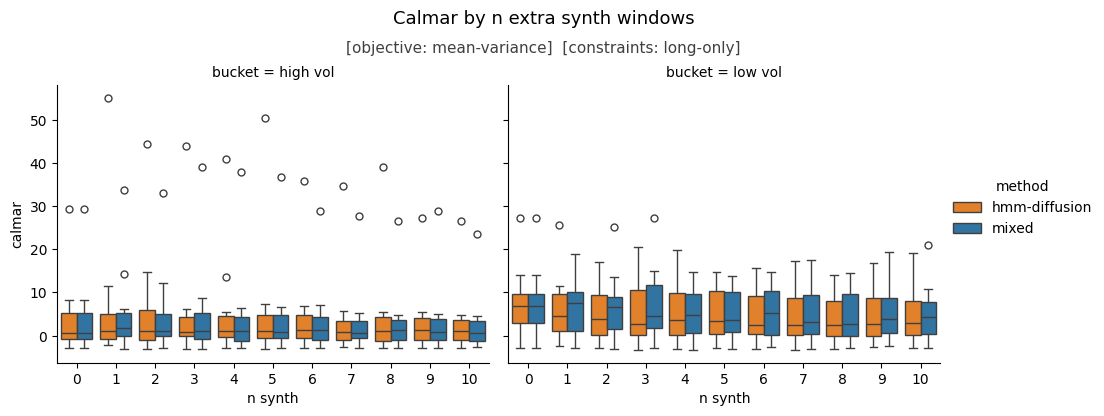

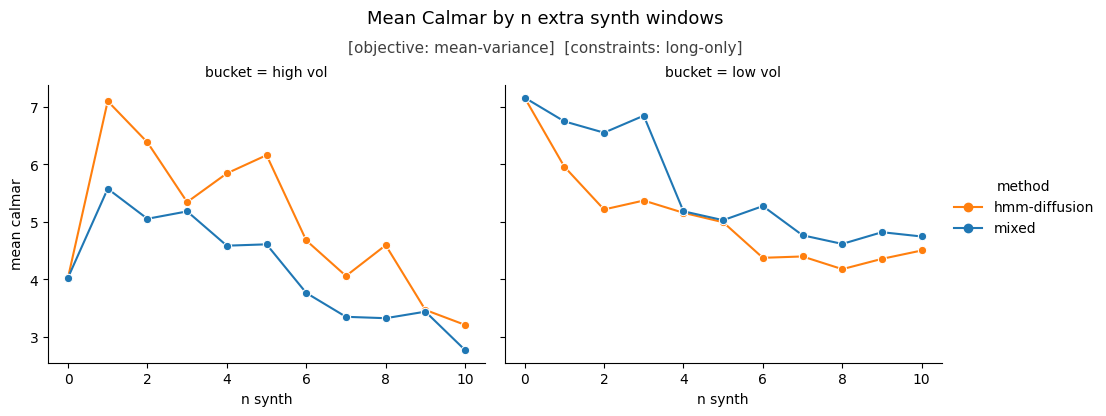

In [10]:
result_long_only = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    val_dates.to_numpy(),
    val_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
)

display(result_long_only.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_long_only.windows, "sharpe", objective="mean-variance", constraint="long-only"
)
plots.plot_mvo_means(
    result_long_only.windows, "sharpe", objective="mean-variance", constraint="long-only"
)
plots.plot_mvo_boxes(
    result_long_only.windows, "calmar", objective="mean-variance", constraint="long-only"
)
plots.plot_mvo_means(
    result_long_only.windows, "calmar", objective="mean-variance", constraint="long-only"
)


## Long-only 30% cap

Same mix, holds, and seeds. After collapse, the 10 traded weights are projected onto `sum w = 1`, `w ≥ 0`, and `w ≤ 0.30`. That is a standard name cap: no asset can be more than 30% of the book. Long-only is applied on the expanded columns first (same as the previous cell), then the cap is enforced on the collapsed 10 names.


,method,n_synth,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,high vol,10,0.6749,0.5293,3.3070,0.7077
22,mixed,0,high vol,10,0.6749,0.5293,3.3070,0.7077
2,hmm-diffusion,1,high vol,10,1.0571,0.6700,5.0706,0.9834
24,mixed,1,high vol,10,1.0640,0.8682,4.4191,1.2843
4,hmm-diffusion,2,high vol,10,1.0883,0.5829,4.8613,0.8861
26,mixed,2,high vol,10,1.1112,0.7901,4.6167,1.0654
6,hmm-diffusion,3,high vol,10,0.9975,0.6016,4.6096,0.8439
28,mixed,3,high vol,10,0.8959,0.7759,4.2247,1.0995
8,hmm-diffusion,4,high vol,10,1.3241,0.7784,5.3021,1.0822
30,mixed,4,high vol,10,0.9085,0.6687,4.2571,0.9602


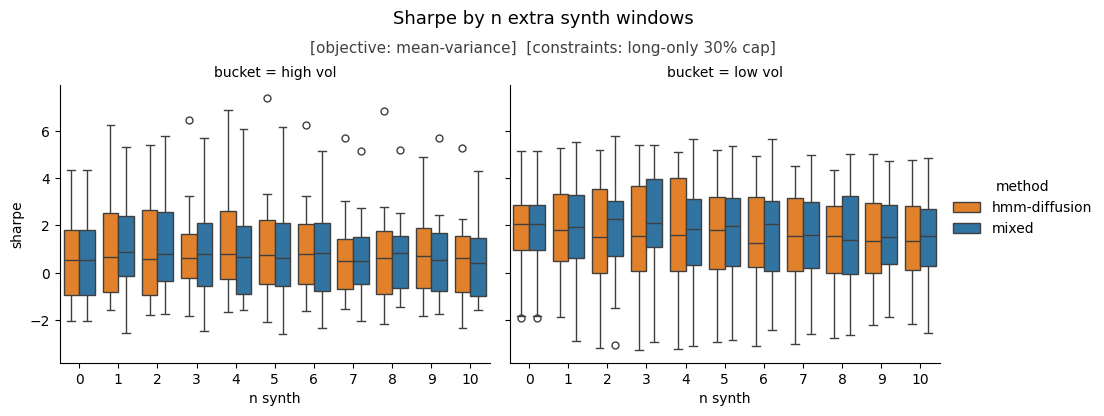

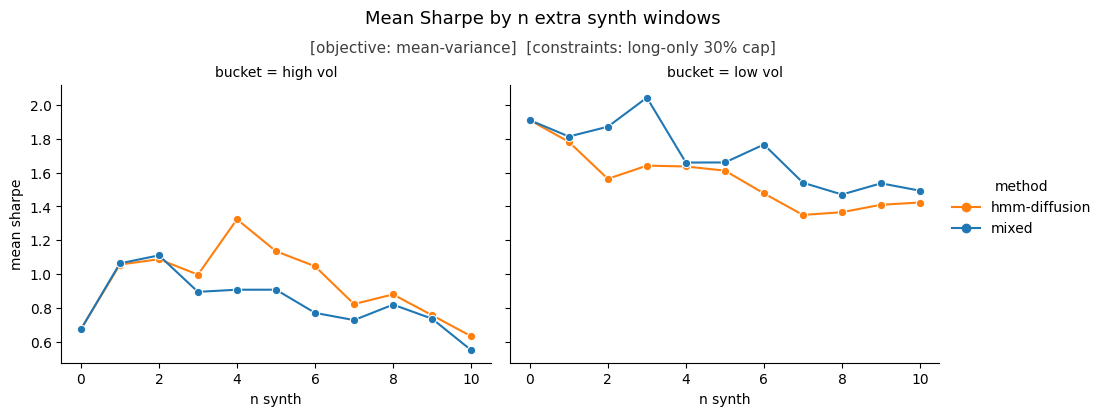

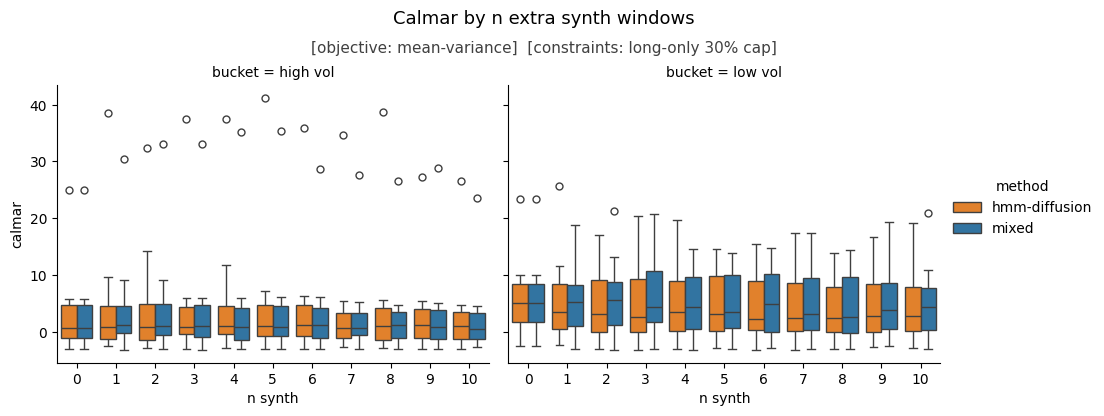

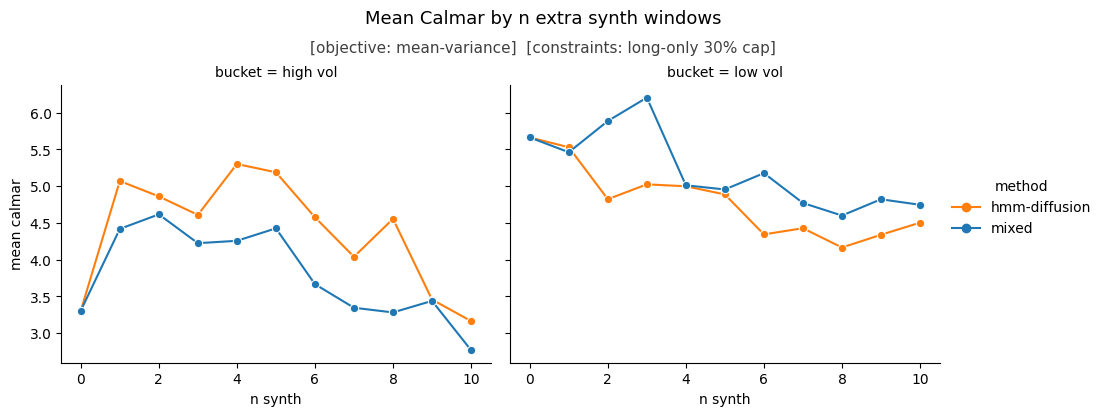

In [11]:
MAX_WEIGHT = 0.30
result_capped = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    val_dates.to_numpy(),
    val_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
)

display(result_capped.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_capped.windows,
    "sharpe",
    objective="mean-variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_capped.windows,
    "sharpe",
    objective="mean-variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_boxes(
    result_capped.windows,
    "calmar",
    objective="mean-variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_capped.windows,
    "calmar",
    objective="mean-variance",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, max Sharpe

Same mix, holds, seeds, long-only, and 30% name cap as the previous cell. Weights maximize Sharpe (`w ∝ Σ^{-1} μ`, rf = 0) on the expanded mix, then collapse, then project onto `w ≥ 0`, `w ≤ 0.30`, `sum w = 1`.


,method,n_synth,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,high vol,10,1.0253,0.7365,4.0407,1.1209
22,mixed,0,high vol,10,1.0253,0.7365,4.0407,1.1209
2,hmm-diffusion,1,high vol,10,1.4538,0.7501,6.2318,1.1574
24,mixed,1,high vol,10,1.4525,1.0741,5.4432,1.5301
4,hmm-diffusion,2,high vol,10,1.5675,0.7418,7.0680,1.0388
26,mixed,2,high vol,10,1.4565,0.8956,5.8129,1.2328
6,hmm-diffusion,3,high vol,10,1.3441,0.8529,5.4943,1.1915
28,mixed,3,high vol,10,1.0816,0.6812,4.6301,0.9260
8,hmm-diffusion,4,high vol,10,1.6755,0.8779,6.8077,1.1762
30,mixed,4,high vol,10,1.3177,0.7859,5.8127,1.1259


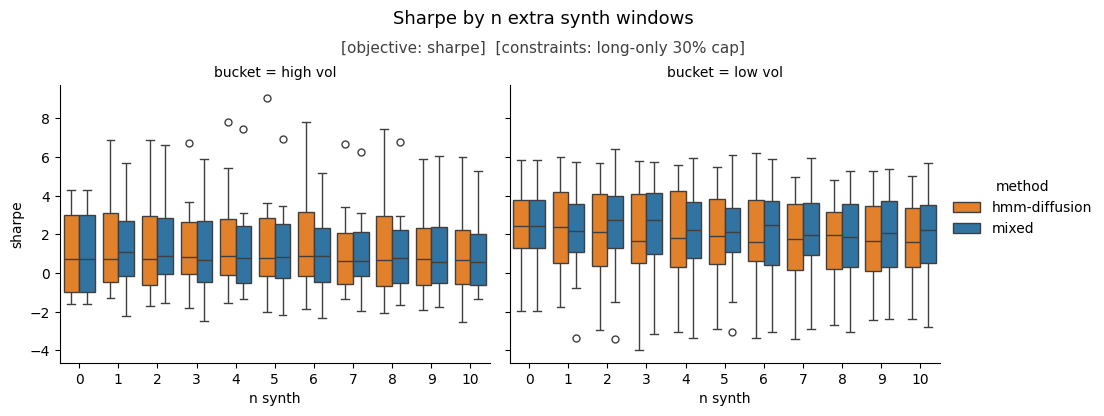

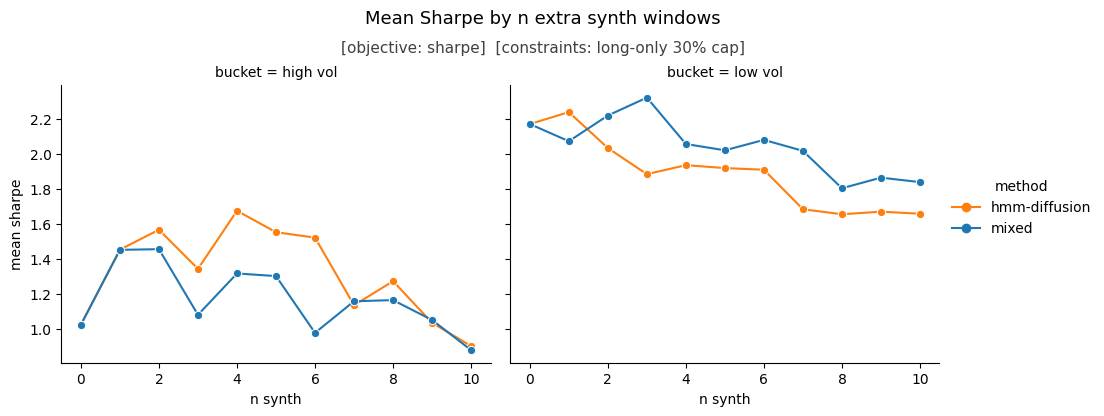

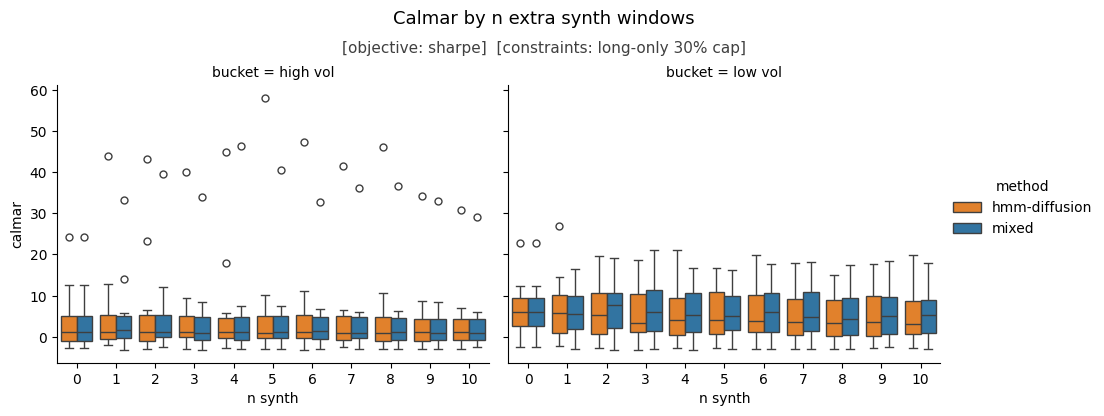

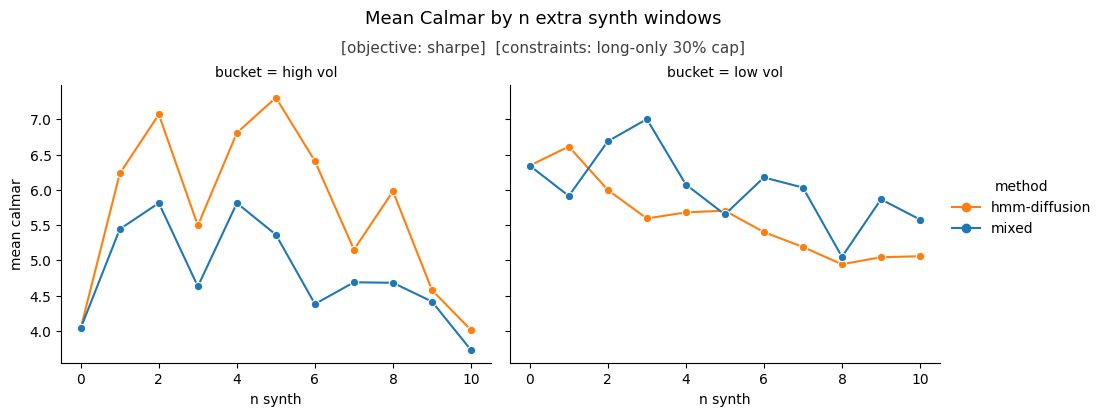

In [12]:
MAX_WEIGHT = 0.30
result_max_sharpe = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    val_dates.to_numpy(),
    val_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="max_sharpe",
)

display(result_max_sharpe.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_max_sharpe.windows,
    "sharpe",
    objective="sharpe",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_max_sharpe.windows,
    "sharpe",
    objective="sharpe",
    constraint="long-only 30% cap",
)
plots.plot_mvo_boxes(
    result_max_sharpe.windows,
    "calmar",
    objective="sharpe",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_max_sharpe.windows,
    "calmar",
    objective="sharpe",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, min variance

Same mix, holds, seeds, long-only, and 30% name cap. Weights are global minimum variance (`w ∝ Σ^{-1} 1`) on the expanded mix, then collapse, then project onto the 30% cap.


,method,n_synth,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,high vol,10,0.7082,0.7231,3.0440,1.1961
22,mixed,0,high vol,10,0.7082,0.7231,3.0440,1.1961
2,hmm-diffusion,1,high vol,10,0.8356,0.6727,3.3272,1.1172
24,mixed,1,high vol,10,0.8145,0.7461,3.3389,1.2090
4,hmm-diffusion,2,high vol,10,1.0091,0.6396,4.4267,1.0396
26,mixed,2,high vol,10,1.2681,0.7662,4.8820,1.1546
6,hmm-diffusion,3,high vol,10,1.0193,0.7155,4.0418,1.1030
28,mixed,3,high vol,10,1.2071,0.7281,5.0771,0.9656
8,hmm-diffusion,4,high vol,10,1.1074,0.6481,4.3172,1.0084
30,mixed,4,high vol,10,1.2633,0.9084,4.6206,1.3878


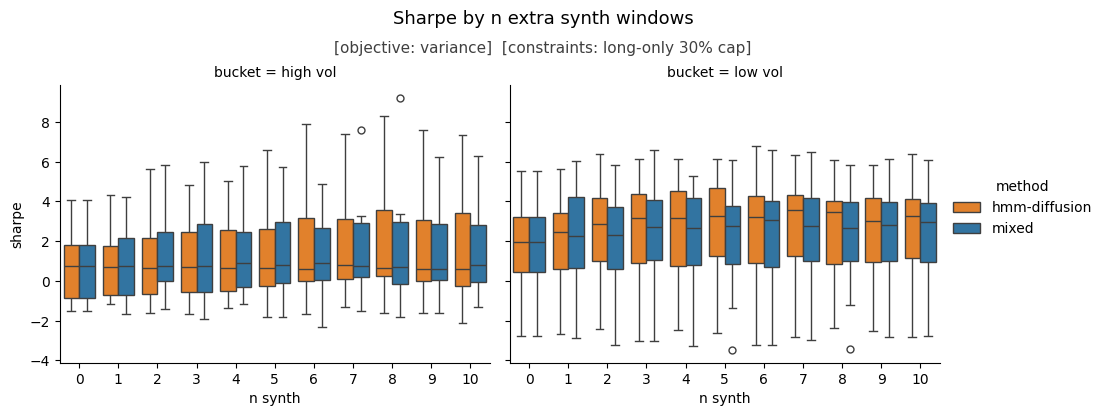

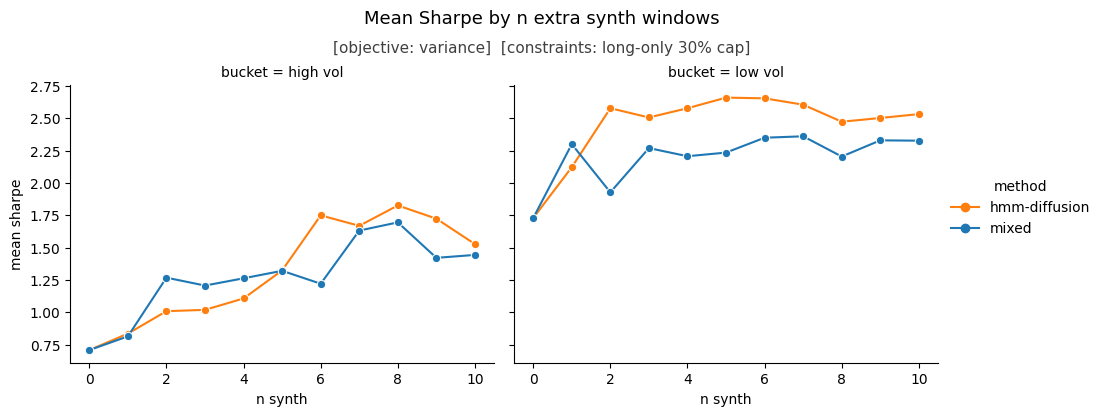

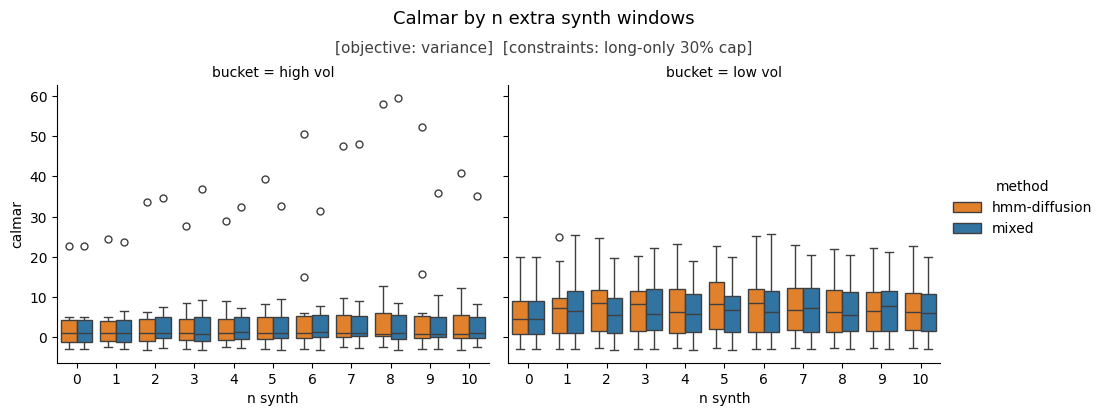

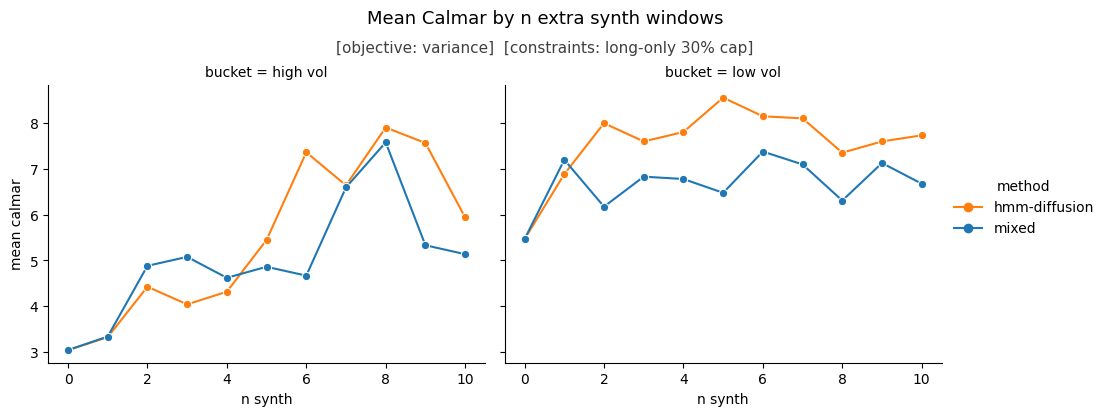

In [13]:
result_min_var = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    val_dates.to_numpy(),
    val_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="min_variance",
)

display(result_min_var.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_min_var.windows,
    "sharpe",
    objective="variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_min_var.windows,
    "sharpe",
    objective="variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_boxes(
    result_min_var.windows,
    "calmar",
    objective="variance",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_min_var.windows,
    "calmar",
    objective="variance",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, max return

Same mix, holds, seeds, long-only, and 30% name cap. After collapse, fill the highest-mean names first: 30% in the best, 30% in the next, and so on, until the weights sum to 1. Covariance is not used.


,method,n_synth,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median
0,hmm-diffusion,0,high vol,10,0.7884,-0.0193,4.2067,0.1775
22,mixed,0,high vol,10,0.7884,-0.0193,4.2067,0.1775
2,hmm-diffusion,1,high vol,10,0.0788,0.1961,1.4292,0.2635
24,mixed,1,high vol,10,0.2971,0.2287,2.1297,0.4738
4,hmm-diffusion,2,high vol,10,0.4626,0.6062,2.2380,1.1106
26,mixed,2,high vol,10,0.2603,0.4709,1.6631,0.8599
6,hmm-diffusion,3,high vol,10,0.1799,0.3002,1.5190,0.6503
28,mixed,3,high vol,10,0.2263,0.3220,1.7847,0.7200
8,hmm-diffusion,4,high vol,10,0.2530,0.6266,1.7548,1.3864
30,mixed,4,high vol,10,0.2149,0.0889,1.9290,0.1775


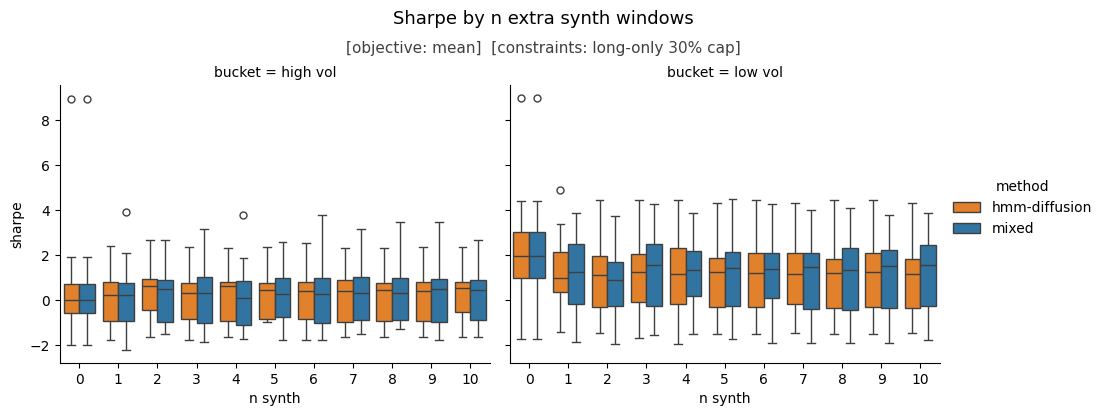

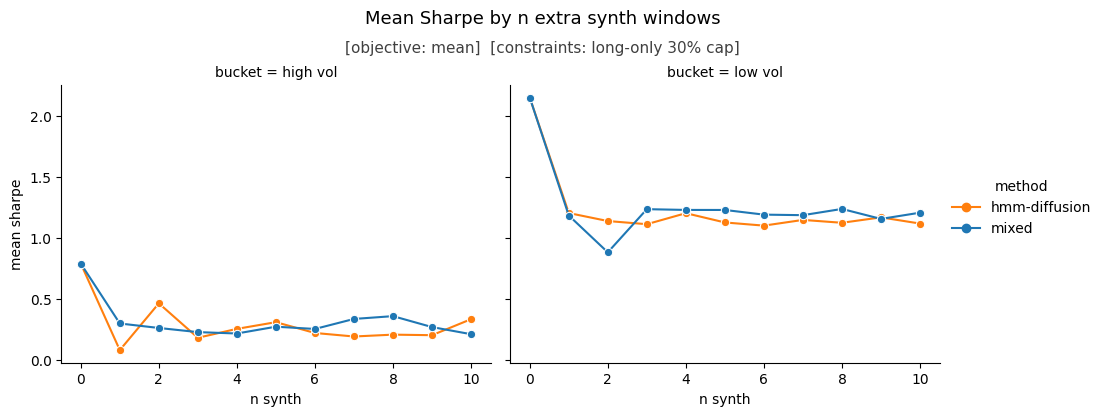

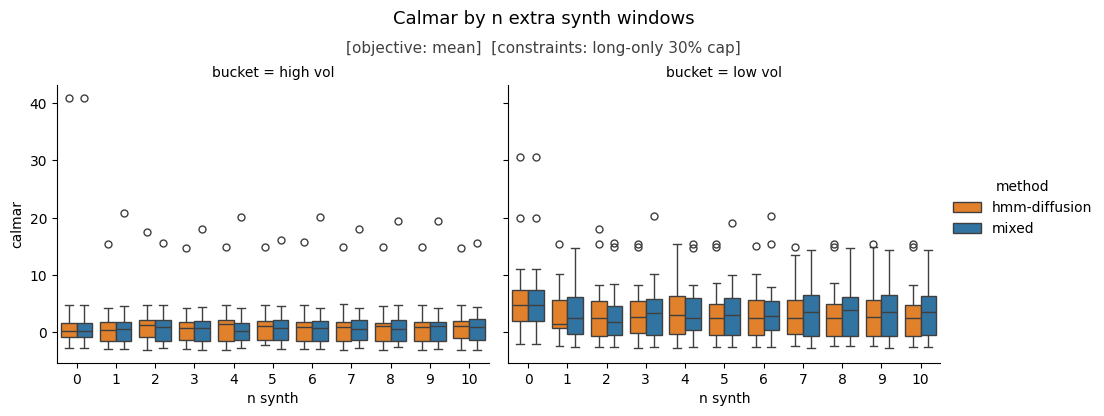

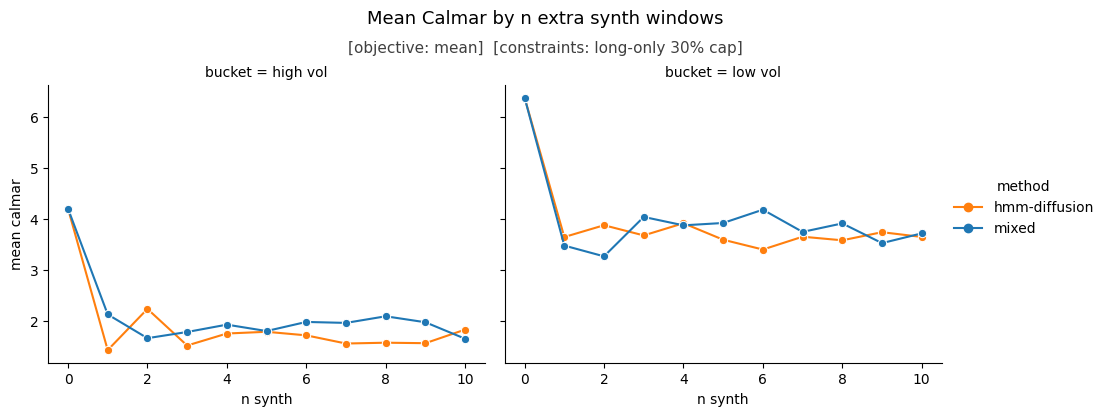

In [14]:
result_max_return = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    val_dates.to_numpy(),
    val_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="max_return",
)

display(result_max_return.summary.sort_values(["bucket", "n_synth", "method"]))
plots.plot_mvo_boxes(
    result_max_return.windows,
    "sharpe",
    objective="mean",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_max_return.windows,
    "sharpe",
    objective="mean",
    constraint="long-only 30% cap",
)
plots.plot_mvo_boxes(
    result_max_return.windows,
    "calmar",
    objective="mean",
    constraint="long-only 30% cap",
)
plots.plot_mvo_means(
    result_max_return.windows,
    "calmar",
    objective="mean",
    constraint="long-only 30% cap",
)
